In [1]:
import os
import numpy as np
import pandas as pd
import pickle
import time
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim

from torch_geometric.data import Dataset
from torch_geometric.data import Data, HeteroData
from torch_geometric.loader import NeighborLoader
from torch_geometric.nn.conv.gcn_conv import gcn_norm
from torch_geometric.nn import global_mean_pool, global_max_pool, global_add_pool

from torch_geometric.utils import scatter

import time
import wandb
from tqdm import tqdm
from collections import Counter
import json
import matplotlib.pyplot as plt
import random

import sys

from pyg_dataset import NetlistDataset

sys.path.append("models/layers/")
from models.model_att import GNN_node
from sklearn.metrics import accuracy_score, precision_score, recall_score


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:


# Function to compute accuracy, precision, and recall
def compute_metrics(true_labels, predicted_labels):
    # Accuracy
    accuracy = accuracy_score(true_labels, predicted_labels)
    
    # Precision
    precision = precision_score(true_labels, predicted_labels, average='binary')
    
    # Recall
    recall = recall_score(true_labels, predicted_labels, average='binary')
    
    return accuracy, precision, recall

### hyperparameter ###
test = False # if only test but not train
restart = False # if restart training
reload_dataset = False # if reload already processed h_dataset

if test:
    restart = True

prediction = 'demand' # one of ['congestion', 'demand']
model_type = "dehnn" #this can be one of ["dehnn", "dehnn_att", "digcn", "digat"] "dehnn_att" might need large memory usage
num_layer = 2 #large number will cause OOM
num_dim = 16 #large number will cause OOM
vn = True #use virtual node or not
trans = False #use transformer or not
aggr = "add" #use aggregation as one of ["add", "max"]
device = "cpu" #use cuda or cpu
learning_rate = 0.0001
num_epochs = 500

if not reload_dataset:
    dataset = NetlistDataset(data_dir="../data/superblue", load_pe = True, pl = True, processed = reload_dataset, load_indices=None)
    h_dataset = []
    for data in tqdm(dataset):
        num_instances = data.node_features.shape[0]
        data.num_instances = num_instances
        data.edge_index_sink_to_net[1] = data.edge_index_sink_to_net[1] - num_instances
        data.edge_index_source_to_net[1] = data.edge_index_source_to_net[1] - num_instances
        
        out_degrees = data.net_features[:, 0]
        mask = (out_degrees < 3000)
        mask_edges = mask[data.edge_index_source_to_net[1]] 
        filtered_edge_index_source_to_net = data.edge_index_source_to_net[:, mask_edges]
        data.edge_index_source_to_net = filtered_edge_index_source_to_net

        mask_edges = mask[data.edge_index_sink_to_net[1]] 
        filtered_edge_index_sink_to_net = data.edge_index_sink_to_net[:, mask_edges]
        data.edge_index_sink_to_net = filtered_edge_index_sink_to_net

        h_data = HeteroData()
        h_data['node'].x = data.node_features
        h_data['net'].x = data.net_features.float()

        
        edge_index = torch.concat([data.edge_index_sink_to_net, data.edge_index_source_to_net], dim=1)
        h_data['node', 'to', 'net'].edge_index, h_data['node', 'to', 'net'].edge_weight = gcn_norm(edge_index, add_self_loops=False)
        h_data['node', 'to', 'net'].edge_type = torch.concat([torch.zeros(data.edge_index_sink_to_net.shape[1]), torch.ones(data.edge_index_source_to_net.shape[1])]).bool()
        h_data['net', 'to', 'node'].edge_index, h_data['net', 'to', 'node'].edge_weight = gcn_norm(edge_index.flip(0), add_self_loops=False)
        
        h_data['design_name'] = data['design_name']
        h_data.num_instances = data.node_features.shape[0]
        variant_data_lst = []

        node_congestion = data.node_congestion.long()
        net_congestion = data.net_congestion.long()
        node_demand = data.node_demand.float()
        net_demand = data.net_demand.float()
        node_demand = (node_demand - torch.mean(node_demand)) / torch.std(node_demand)
        net_demand = (net_demand - torch.mean(net_demand))/ torch.std(net_demand)
        
        batch = data.batch
        num_vn = len(np.unique(batch))
        vn_node = torch.concat([global_mean_pool(h_data['node'].x, batch), 
                global_max_pool(h_data['node'].x, batch)], dim=1)

        variant_data_lst.append((node_demand, net_demand, node_congestion, net_congestion, batch, num_vn, vn_node)) 
        h_data['variant_data_lst'] = variant_data_lst
        h_dataset.append(h_data)
        
    torch.save(h_dataset, "h_dataset.pt")
    
else:
    dataset = torch.load("h_dataset.pt")
    h_dataset = []
    for data in dataset:
        h_dataset.append(data)
    
sys.path.append("models/layers/")



Fatal Python error: config_get_locale_encoding: failed to get the locale encoding: nl_langinfo(CODESET) failed
Python runtime state: preinitialized

100%|███████████████████████████████████████████| 12/12 [00:01<00:00, 11.69it/s]


In [3]:
X_train_list = []
y_train_list_r = []
y_train_list_c = []
X_test_list = []
y_test_list_r = []
y_test_list_c = []
for i in range(10):
    X_train_list.append(h_dataset[i]["node"]["x"])
    y_train_list_r.append(h_dataset[i]["variant_data_lst"][0][0])
    y_train_list_c.append(h_dataset[i]["variant_data_lst"][0][2])
for i in range(10,12):
    X_test_list.append(h_dataset[i]["node"]["x"])
    y_test_list_r.append(h_dataset[i]["variant_data_lst"][0][0])        
    y_test_list_c.append(h_dataset[i]["variant_data_lst"][0][2])   

In [4]:
X_train = torch.cat(X_train_list, dim=0).numpy()
y_train_reg = torch.cat(y_train_list_r, dim=0).numpy()
y_train_clf = torch.cat(y_train_list_c, dim=0).numpy()
y_train_clf = np.where(y_train_clf <= 0.9, 0, 1)
X_test = torch.cat(X_test_list, dim=0).numpy()
y_test_reg = torch.cat(y_test_list_r, dim=0).numpy()
y_test_clf = torch.cat(y_test_list_c, dim=0).numpy()
y_test_clf = np.where(y_test_clf <= 0.9, 0, 1)

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

In [6]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
import shap

In [7]:
train_data = lgb.Dataset(X_train, label=y_train_reg)
valid_data = lgb.Dataset(X_test, label=y_test_reg)

In [11]:
start = time.time()
params = {
    "objective": "regression",
    "metric": "rmse",  # Root Mean Squared Error
    "boosting_type": "gbdt",  # Gradient Boosting Decision Tree
    "learning_rate": 0.1,
    "num_leaves": 31,  # Controls tree complexity
    "max_depth": -1,  # No depth limit
    "feature_fraction": 0.9,  # Randomly select 80% of features per tree
    "bagging_fraction": 0.8,  # Randomly select 80% of data per tree
    "bagging_freq": 5,  # Perform bagging every 5 iterations
    "verbose": -1,
}
model = lgb.train(
    params,
    train_data,
    valid_sets=[valid_data],
    num_boost_round=500,  # Max trees
)
print(time.time()-start)

33.27570366859436


In [13]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test_reg, y_pred)
print(f"Validation MSE: {mse}")

Validation MSE: 1.107208669785989


In [14]:
y_pred = model.predict(X_train)
mse = mean_squared_error(y_train_reg, y_pred)
print(f"Validation MSE: {mse}")

Validation MSE: 0.6373353246427369


In [17]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

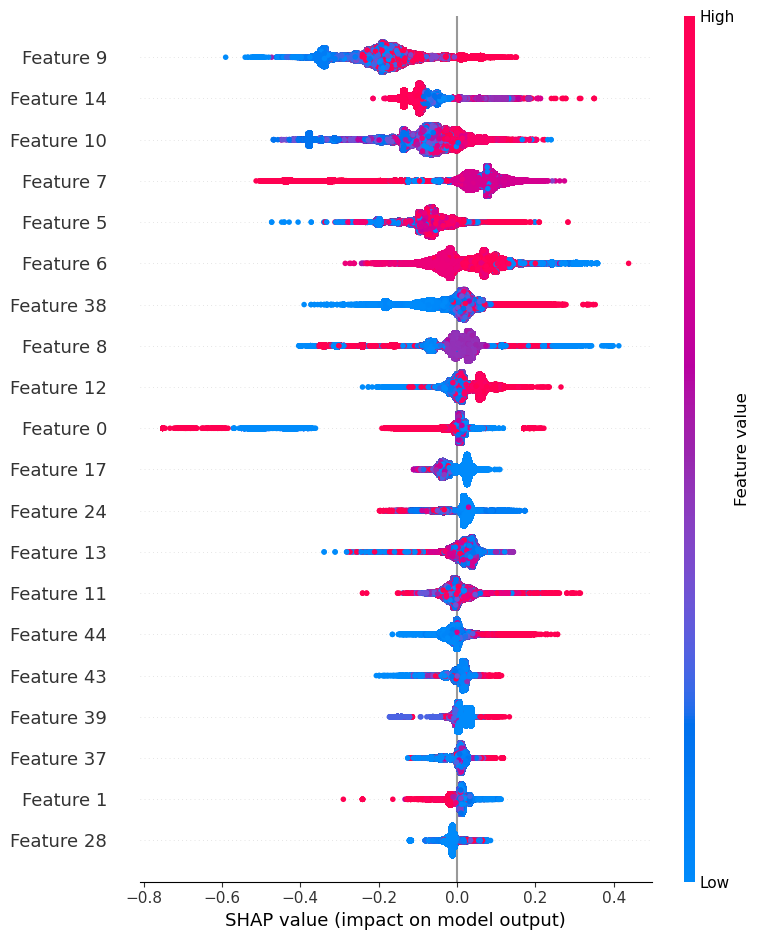

In [18]:
shap.summary_plot(shap_values, X_test)